### For each cell type shared, perform the comparison between our DEG list (using pseudobulked analysis) and Read DEG list

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
def extract_significant(df, direction, logFC_threshold = 0.5, p_val_threshold = 0.05):
    '''Get either the significant up or down DEGs from a pydeseq2 directory''' 
    if direction == "up":
        sig_df = df[(df['log2FoldChange'] > logFC_threshold) & (df['padj'] < p_val_threshold)].copy()
        sig_df['direction']  = direction
    elif direction == "down":
        sig_df = df[(df['log2FoldChange'] < -logFC_threshold) & (df['padj'] < p_val_threshold)].copy()
        sig_df['direction']  = direction
    else: 
        raise ValueError("direction must be 'up' or 'down'!")
    return sig_df

In [3]:
def compare_DEGs(our_df, read_df, our_gene_col="gene_id", read_gene_col="gene", 
                 our_direction_col="direction", read_direction_col = "Effect_Direction"):
    '''Compare DEGs between our dataset and Read et al.'''
    
    # generate sets
    our_up   = set(our_df.loc[our_df[our_direction_col]=="up",   our_gene_col])
    our_down = set(our_df.loc[our_df[our_direction_col]=="down", our_gene_col])
    
    read_up   = set(read_df.loc[read_df[read_direction_col]=="Positive",   read_gene_col])
    read_down = set(read_df.loc[read_df[read_direction_col]=="Negative", read_gene_col])
    
    results = {
        "shared_up":   len(our_up & read_up),
        "shared_down": len(our_down & read_down),
        "up_only_ours": len(our_up - read_up),
        "down_only_ours": len(our_down - read_down),
        "up_only_Read": len(read_up - our_up),
        "down_only_Read": len(read_down - our_down),
    }
    
    return results

### Test for one cell type

In [4]:
Read_DEG_df = pd.read_csv("Read_age_DEG_df/Adipocyte_DEG.csv", index_col = 0)
Read_DEG_df

,gene,coefficientValue,q_val,pval,cellType,Effect_Magnitude,Effect_Direction,consistent_cell_type
67494,PDLIM3,0.047694,0.036097,6.142400e-05,Adipocytes,0.047694,Positive,Adipocyte
67495,AC002316.1,0.046212,0.014149,1.805704e-05,Adipocytes,0.046212,Positive,Adipocyte
67496,NR4A1,0.044988,0.036097,6.106190e-05,Adipocytes,0.044988,Positive,Adipocyte
67501,GLDN,-0.038601,0.006939,9.839545e-07,Adipocytes,0.038601,Negative,Adipocyte
67503,JUN,0.038287,0.049231,1.047172e-04,Adipocytes,0.038287,Positive,Adipocyte
67557,NLGN1,0.024783,0.010062,9.987549e-06,Adipocytes,0.024783,Positive,Adipocyte
67558,TMX4,0.024733,0.009601,6.528548e-06,Adipocytes,0.024733,Positive,Adipocyte
67559,NAV3,0.024623,0.009601,6.338927e-06,Adipocytes,0.024623,Positive,Adipocyte
67631,AASS,-0.019443,0.009601,7.534423e-06,Adipocytes,0.019443,Negative,Adipocyte
67638,GPHN,-0.019291,0.009601,6.934080e-06,Adipocytes,0.019291,Negative,Adipocyte


In [5]:
our_DEG_df = pd.read_csv("../pydeseq2_results/Adipocyte_age_group_old_vs_young_results.csv", index_col = 0)
our_DEG_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,-log10(padj),significant
COL27A1,19.647560,-3.825358,0.545459,-7.013098,2.330978e-12,1.423528e-08,COL27A1,7.846634,True
ACTN1,56.108294,-1.986348,0.340905,-5.826690,5.653751e-09,1.726373e-05,ACTN1,4.762865,True
HS2ST1,36.501151,-1.367322,0.270431,-5.056088,4.279430e-07,8.711493e-04,HS2ST1,3.059907,True
ZBTB7C,53.384308,-1.935981,0.392505,-4.932377,8.123491e-07,9.922032e-04,ZBTB7C,3.003399,True
GLDN,36.286226,-2.756296,0.557118,-4.947422,7.520291e-07,9.922032e-04,GLDN,3.003399,True
...,...,...,...,...,...,...,...,...,...
MYH6,15.947856,-0.000207,0.826151,-0.000250,9.998002e-01,9.998002e-01,MYH6,0.000087,False
C1S,21.809223,-0.000097,0.298137,-0.000327,9.997395e-01,9.998002e-01,C1S,0.000087,False
ZNF138,8.165539,0.000199,0.305911,0.000651,9.994802e-01,9.998002e-01,ZNF138,0.000087,False
HEXA,9.250605,-0.000100,0.271238,-0.000370,9.997050e-01,9.998002e-01,HEXA,0.000087,False


In [6]:
sig_df = extract_significant(our_DEG_df, direction="up")
sig_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,-log10(padj),significant,direction
SGCG,14.212922,1.713854,0.407411,4.206694,0.000026,0.007536,SGCG,2.122867,True,up
CCDC69,22.738357,1.107134,0.283806,3.901017,0.000096,0.015394,CCDC69,1.812639,True,up
ZER1,12.548872,1.046983,0.281070,3.724985,0.000195,0.023603,ZER1,1.627036,True,up
GLE1,7.177759,1.127558,0.301905,3.734809,0.000188,0.023603,GLE1,1.627036,True,up
SCPEP1,9.856086,1.321735,0.354374,3.729773,0.000192,0.023603,SCPEP1,1.627036,True,up
FAM114A1,18.596186,0.792906,0.229791,3.450555,0.000559,0.041664,FAM114A1,1.380236,True,up
SIRT2,8.064198,1.060301,0.307962,3.442962,0.000575,0.041831,SIRT2,1.378497,True,up
WIPI1,11.775889,1.091751,0.318238,3.430608,0.000602,0.041974,WIPI1,1.377021,True,up
HEBP2,30.158904,0.820081,0.243712,3.364964,0.000766,0.047705,HEBP2,1.321432,True,up
NRG2,13.287731,1.115175,0.333503,3.343818,0.000826,0.048995,NRG2,1.309852,True,up


### Iterate through all cell types

In [7]:
shared_cell_types = ['Adipocyte', 'Cardiomyocyte', 'Endothelial', 'Fibroblast', 'Lymphoid', 'Neuronal', 'Pericyte']

In [8]:
results_list = list()

for cell_type in shared_cell_types:

    # load in the Read df (NEBULA) and our DEG df (pseudobulked method)
    Read_DEG_df = pd.read_csv("Read_age_DEG_df/" + cell_type + "_DEG.csv", index_col = 0)
    our_DEG_df = pd.read_csv("../pydeseq2_results/" + cell_type + "_age_group_old_vs_young_results.csv", index_col = 0)

    # extract significant up DEGs
    sig_up_df = extract_significant(our_DEG_df, direction="up")
    sig_down_df = extract_significant(our_DEG_df, direction="down")
    concat_sig_df = pd.concat([sig_up_df, sig_down_df])
    
    # compare up DEGs
    results = compare_DEGs(our_df=concat_sig_df, read_df=Read_DEG_df)
    results['cell_type'] = cell_type

    # append both
    results_list.append(results)

results_df = pd.DataFrame(results_list)

In [9]:
results_df

,shared_up,shared_down,up_only_ours,down_only_ours,up_only_Read,down_only_Read,cell_type
0,0,1,10,94,7,7,Adipocyte
1,10,4,40,89,252,437,Cardiomyocyte
2,0,0,0,1,2,0,Endothelial
3,5,1,42,39,10,12,Fibroblast
4,0,0,0,1,1,2,Lymphoid
5,0,0,3,39,8,16,Neuronal
6,0,1,14,9,0,0,Pericyte


/mnt/data1/william/tmp/ipykernel_1149346/2708187481.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heatmap_colors = heatmap_df.applymap(lambda x: np.log1p(x))


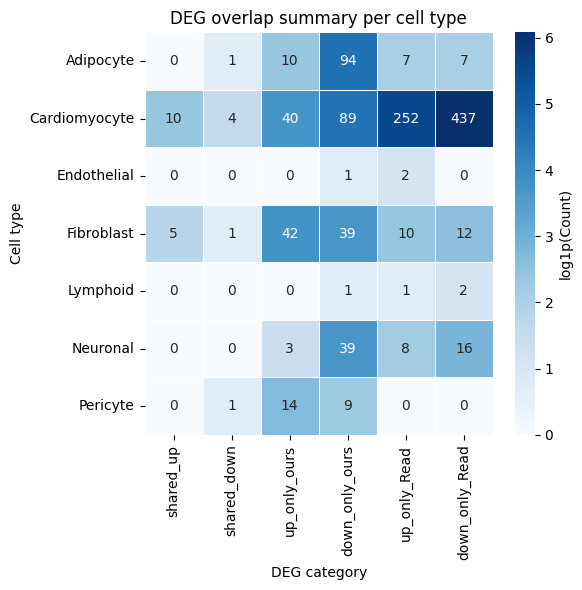

In [10]:
# Select metrics
heatmap_df = results_df.set_index("cell_type")[
    ["shared_up", "shared_down", "up_only_ours", "down_only_ours", "up_only_Read", "down_only_Read"]
]

custom_order = shared_cell_types

heatmap_df = heatmap_df.reindex(custom_order)

# Color values on log scale
heatmap_colors = heatmap_df.applymap(lambda x: np.log1p(x))

plt.figure(figsize=(6,6))
sns.heatmap(
    heatmap_colors,
    cmap="Blues",           
    annot=heatmap_df,      
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "log1p(Count)"}
)
plt.title("DEG overlap summary per cell type")
plt.ylabel("Cell type")
plt.xlabel("DEG category")
plt.tight_layout()

plt.savefig("Read_vs_our_study_aging_DEGs.pdf")
plt.show()

### Examine the shared genes

In [19]:
def identify_shared_DEGs(
    our_df, read_df,
    our_gene_col="gene_id", read_gene_col="gene",
    our_direction_col="direction", read_direction_col="Effect_Direction"
):
    '''
    Compare DEGs between our dataset and Read et al.
    '''
    
    # generate sets
    our_up   = set(our_df.loc[our_df[our_direction_col]=="up",   our_gene_col])
    our_down = set(our_df.loc[our_df[our_direction_col]=="down", our_gene_col])
    
    read_up   = set(read_df.loc[read_df[read_direction_col]=="Positive", read_gene_col])
    read_down = set(read_df.loc[read_df[read_direction_col]=="Negative", read_gene_col])
    
    results = {
        "shared_up":   our_up & read_up,
        "shared_down": our_down & read_down,
        "up_only_ours": our_up - read_up,
        "down_only_ours": our_down - read_down,
        "up_only_read": read_up - our_up,
        "down_only_read": read_down - our_down,
    }
    
    return results

In [20]:
# container list
shared_genes_list = []

for cell_type in shared_cell_types:

    # load in the Read df (NEBULA) and our DEG df (pseudobulked method)
    Read_DEG_df = pd.read_csv(f"Read_age_DEG_df/{cell_type}_DEG.csv", index_col=0)
    our_DEG_df  = pd.read_csv(f"../pydeseq2_results/{cell_type}_age_group_old_vs_young_results.csv", index_col=0)

    # extract significant up & down DEGs
    sig_up_df   = extract_significant(our_DEG_df, direction="up")
    sig_down_df = extract_significant(our_DEG_df, direction="down")
    concat_sig_df = pd.concat([sig_up_df, sig_down_df])
    
    # compare DEGs
    results = identify_shared_DEGs(our_df=concat_sig_df, read_df=Read_DEG_df)
    results["cell_type"] = cell_type  # add annotation
    
    # append to list
    shared_genes_list.append(results)


# turn into DataFrame
results_df = pd.DataFrame(shared_genes_list)

In [21]:
results_df

,shared_up,shared_down,up_only_ours,down_only_ours,up_only_read,down_only_read,cell_type
0,{},{GLDN},"{SCPEP1, NRG2, CCDC69, GLE1, FAM114A1, WIPI1, ...","{G3BP1, ABCE1, HIF1A, NRCAM, DPYSL2, GALNT1, E...","{NAV3, JUN, NLGN1, AC002316.1, TMX4, PDLIM3, N...","{JAG1, YTHDF3, CDC73, AASS, GPHN, COP1, CUL3}",Adipocyte
1,"{SLC24A2, MDGA1, RALYL, COL28A1, PTCHD4, CNTN1...","{PYGO1, UTRN, PTGER3, STARD4}","{RBM26-AS1, ANKS4B, F11-AS1, STK24-AS1, TEKT3,...","{COL6A3, LDLR, ZFYVE28, EMILIN1, CILP, RASSF7,...","{ZFAND5, BCL7B, CFAP47, GRIK4, SH3BGR, IRF2BP2...","{GNPTAB, FAM126A, NEO1, ACADM, RAP1GDS1, FASTK...",Cardiomyocyte
2,{},{},{},{COL3A1},"{RIMS1, LRP1B}",{},Endothelial
3,"{EPHA6, PPP2R2B, LRRIQ1, XG, ARHGEF28}",{RANBP17},"{HBA2, CSMD3, FAM133A, MEGF10, LMX1A, OPALIN, ...","{ABCC9, ASPM, HK2, SLC16A10, TMEM59L, NPY5R, N...","{TP63, VPS33B, CP, PRUNE2, THSD7B, CREB5, SHAN...","{ANKHD1, SRSF11, ZNF207, NAA38, API5, DDHD2, C...",Fibroblast
4,{},{},{},{COL3A1},{MRPS28},"{LMBR1L, CALCOCO1}",Lymphoid
5,{},{},"{ITLN1, PTCHD4, ZER1}","{CTSC, ANXA2, C1S, NRCAM, UGCG, BCL3, BHLHE40,...","{CABIN1, NXN, DAB1, BCL2L14, DDI2, KCNIP4, ZNF...","{RBM25, NPNT, PCBP2, CNTN4, SLC22A15, FAM114A1...",Neuronal
6,{},{RANBP17},"{SPATA18, TSHZ2, TMEM200C, RERGL, RGS6, TNNI3,...","{COL1A2, CCDC102B, KCNQ1OT1, NBPF14, MSC, GGT5...",{},{},Pericyte


In [23]:
results_df['shared_up'][1]

{'B3GALT5',
 'CNTN1',
 'COL28A1',
 'KCTD8',
 'MDGA1',
 'NOS1',
 'PTCHD4',
 'RALYL',
 'SHBG',
 'SLC24A2'}

In [24]:
results_df['shared_up'][3]

{'ARHGEF28', 'EPHA6', 'LRRIQ1', 'PPP2R2B', 'XG'}